# Deep Q-Network (DQN) — Paper Details and All Tricks

Mnih et al., **"Human-level control through deep reinforcement learning"**, *Nature* 518, 529–533 (2015).

This notebook walks through every component and design trick in the original DQN paper,
implements each one from scratch in PyTorch, and runs ablation experiments to show
the contribution of each piece.

**Environment:** CartPole-v1 (fast to train on CPU; Atari-specific tricks are explained with code
but not executed — no ROM required).  
**Runtime:** ≈ 5–10 min on CPU.

## Outline

| # | Section | DQN Trick |
|---|---------|----------|
| 1 | Background & Motivation | Why Q-learning + NN is hard |
| 2 | Environment | CartPole-v1 setup |
| 3 | Atari Preprocessing | Grayscale, resize, frame stacking, frame skipping |
| 4 | Q-Network Architecture | CNN (Atari) vs MLP (CartPole) |
| 5 | Experience Replay | Breaks temporal correlations, improves data efficiency |
| 6 | Target Network | Stabilises TD targets |
| 7 | Exploration | ε-greedy with linear annealing |
| 8 | Loss & Reward | Huber loss (clipped gradient) + reward clipping |
| 9 | Full DQN Agent | All tricks combined |
| 10 | Ablation Studies | Effect of removing each trick |

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random
import copy
import gymnasium as gym
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

# ── Reproducibility ─────────────────────────────────────────────────────────
GLOBAL_SEED = 42
torch.manual_seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  gymnasium {gym.__version__}  |  device: {device}')

# ── Utility ──────────────────────────────────────────────────────────────────
def smooth(x, window=20):
    """Moving-average smoothing; returns shorter array (mode='valid')."""
    if window <= 1 or len(x) < window:
        return np.array(x)
    return np.convolve(x, np.ones(window) / window, mode='valid')

PyTorch 2.4.1  |  gymnasium 1.2.3  |  device: cpu


---
## 1 — Background: Why Q-Learning + Neural Network is Hard

### Q-learning recap

The optimal Q-function satisfies the Bellman optimality equation:
$$Q^*(s,a) = \mathbb{E}\!\left[r + \gamma\max_{a'}Q^*(s',a') \mid s,a\right]$$

Tabular Q-learning updates:
$$Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha\Bigl[\underbrace{r_t + \gamma\max_{a'}Q(s_{t+1},a')}_{\text{target }y_t} - Q(s_t,a_t)\Bigr]$$

### Three sources of instability with function approximation

Replace the table with a neural network $Q(s,a;\theta)$ and naively minimise
$\mathcal{L}(\theta) = \mathbb{E}[(y_t - Q(s_t,a_t;\theta))^2]$:

| Problem | Cause | DQN Fix |
|---------|-------|---------|
| **Correlated data** | Consecutive transitions $(s_t,a_t,r_t,s_{t+1})$ are highly correlated; violates i.i.d. SGD assumption | **Experience Replay** |
| **Moving targets** | $y_t$ depends on $\theta$ — targets shift every gradient step ("chasing a moving target") | **Target Network** |
| **Non-stationary distribution** | Policy changes → data distribution changes → feedback loops | Both above |

The cell below visualises problem (1).

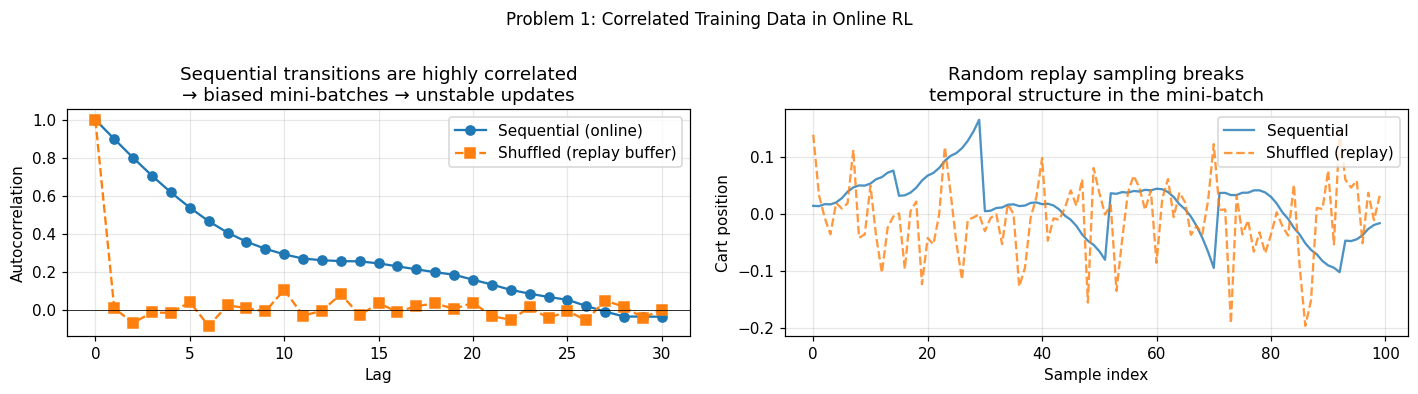

In [3]:
# ── Demonstrate temporal correlations in online RL data ──────────────────────
env_demo = gym.make('CartPole-v1')
state, _ = env_demo.reset(seed=0)
sequential_obs = []
for _ in range(500):
    action = env_demo.action_space.sample()
    next_state, _, terminated, truncated, _ = env_demo.step(action)
    sequential_obs.append(state[0])   # cart position
    state = next_state
    if terminated or truncated:
        state, _ = env_demo.reset()
env_demo.close()

sequential_obs = np.array(sequential_obs)
shuffled_obs = sequential_obs.copy()
np.random.shuffle(shuffled_obs)

def autocorr(x, max_lag=30):
    x = x - x.mean()
    result = np.correlate(x, x, mode='full')
    result = result[len(x)-1:] / result[len(x)-1]
    return result[:max_lag+1]

lags = np.arange(31)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

ax = axes[0]
ax.plot(lags, autocorr(sequential_obs), 'C0o-', label='Sequential (online)', lw=1.5)
ax.plot(lags, autocorr(shuffled_obs),   'C1s--', label='Shuffled (replay buffer)', lw=1.5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Lag'); ax.set_ylabel('Autocorrelation')
ax.set_title('Sequential transitions are highly correlated\n→ biased mini-batches → unstable updates')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(sequential_obs[:100], label='Sequential', alpha=0.8, lw=1.5)
ax.plot(shuffled_obs[:100],   label='Shuffled (replay)', alpha=0.8, lw=1.5, linestyle='--')
ax.set_xlabel('Sample index'); ax.set_ylabel('Cart position')
ax.set_title('Random replay sampling breaks\ntemporal structure in the mini-batch')
ax.legend(); ax.grid(True, alpha=0.3)

fig.suptitle('Problem 1: Correlated Training Data in Online RL', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

---
## 2 — Environment: CartPole-v1

We use **CartPole-v1** as our training environment — fast enough to run ablations on CPU.

| | CartPole-v1 | Atari (e.g. Breakout) |
|---|---|---|
| **State** | 4 floats | 84×84×4 uint8 pixels |
| **Actions** | 2 (left / right) | 4–18 discrete |
| **Reward** | +1 per step | Game score delta |
| **Episode end** | Pole falls or cart exits | Life lost / timeout |
| **Solved** | Avg ≥ 475 over 100 ep | Human-level score |

The core DQN components (replay, target network, ε-greedy) are **identical** across environments.
Only the network architecture and preprocessing change.

In [4]:
env = gym.make('CartPole-v1')
obs, _ = env.reset(seed=0)

print('Observation space:', env.observation_space)
print('Action space:     ', env.action_space)
print('Sample state:     ', obs)
print('Dimensions:        cart_pos, cart_vel, pole_angle, pole_ang_vel')

# Random-policy baseline
ep_rewards = []
for _ in range(20):
    o, _ = env.reset()
    total, done = 0.0, False
    while not done:
        o, r, term, trunc, _ = env.step(env.action_space.sample())
        total += r; done = term or trunc
    ep_rewards.append(total)
env.close()

print(f'\nRandom policy → mean episode reward: {np.mean(ep_rewards):.1f} ± {np.std(ep_rewards):.1f}')
print(f'DQN target   → ≥ 475 (max = 500 with time-limit)')

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space:      Discrete(2)
Sample state:      [ 0.01369617 -0.02302133 -0.04590265 -0.04834723]
Dimensions:        cart_pos, cart_vel, pole_angle, pole_ang_vel

Random policy → mean episode reward: 19.8 ± 9.1
DQN target   → ≥ 475 (max = 500 with time-limit)


---
## 3 — Atari Preprocessing

### Why preprocess?
Raw Atari frames are 210×160 RGB images (~100 KB each). The DQN paper applies a fixed pipeline:

```
Raw frame 210×160×3 (RGB)
    ↓  Convert to luminance: Y = 0.299R + 0.587G + 0.114B
    ↓  Resize to 84×84 (bilinear)
    ↓  Store as uint8  ← memory-efficient replay buffer
    ↓  Stack last 4 frames  → 4×84×84 tensor  ← motion / velocity
    ↓  Divide by 255 before network forward pass
```

### Frame stacking — encoding temporal information
A single frame gives position but not velocity. Stacking **4 consecutive frames** lets the
network infer motion without recurrence (RNN).

### Action repeat (frame skipping)
The selected action is **repeated for 4 frames** before a new action is chosen.
Only the max over the last 2 frames is used (to handle sprite flickering in some games).
Benefits: faster training (fewer decisions) and smoother effective action space.

### Memory cost
Storing 1M transitions naively: `2 × 84 × 84 × 3 ≈ 42 MB` per transition → **42 TB**.
Fix: store only single frames and reconstruct stacks on sampling → **~6–8 GB**.

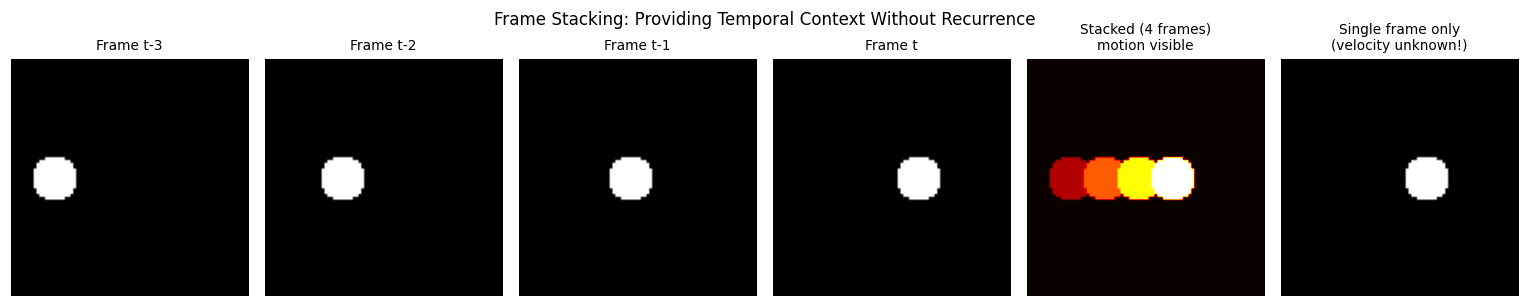

In [5]:
# ── Atari preprocessing (for illustration — no ROM required) ─────────────────

class AtariPreprocessing:
    """
    Atari frame preprocessing as in Mnih et al. 2015.
    Wraps a gymnasium Atari environment.
    """
    def __init__(self, env, frame_stack: int = 4, screen_size: int = 84):
        self.env = env
        self.frame_stack = frame_stack
        self.screen_size = screen_size
        self.frames: deque = deque(maxlen=frame_stack)

    @staticmethod
    def _to_grayscale_and_resize(frame: np.ndarray, size: int = 84) -> np.ndarray:
        """Convert RGB (H,W,3) uint8 → grayscale (size,size) float32 in [0,1]."""
        from PIL import Image
        # ITU-R BT.601 luminance
        gray = (0.299 * frame[:,:,0] + 0.587 * frame[:,:,1] + 0.114 * frame[:,:,2])
        img  = Image.fromarray(gray.astype(np.uint8)).resize((size, size), Image.BILINEAR)
        return np.asarray(img, dtype=np.float32) / 255.0

    def reset(self):
        obs, info = self.env.reset()
        frame = self._to_grayscale_and_resize(obs, self.screen_size)
        for _ in range(self.frame_stack):           # fill stack with first frame
            self.frames.append(frame)
        return np.stack(self.frames), info          # (4, 84, 84)

    def step(self, action):
        obs, reward, term, trunc, info = self.env.step(action)
        self.frames.append(self._to_grayscale_and_resize(obs, self.screen_size))
        return np.stack(self.frames), reward, term, trunc, info

# ── Visualise frame stacking on synthetic data ───────────────────────────────
fig, axes = plt.subplots(1, 6, figsize=(14, 2.8))
cx_positions = [15, 27, 39, 51]          # ball moving right
yy, xx = np.ogrid[:84, :84]

frames = []
for i, cx in enumerate(cx_positions):
    img = np.zeros((84, 84))
    img[(xx - cx)**2 + (yy - 42)**2 < 64] = 1.0
    frames.append(img)
    axes[i].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f'Frame t{-3+i:+d}' if i < 3 else 'Frame t', fontsize=9)
    axes[i].axis('off')

# Stack: visualise as max-projection to show motion trail
stack = np.max(np.stack([f * (0.25 * (k+1)) for k, f in enumerate(frames)], axis=0), axis=0)
axes[4].imshow(stack, cmap='hot', vmin=0, vmax=1)
axes[4].set_title('Stacked (4 frames)\nmotion visible', fontsize=9)
axes[4].axis('off')

# Show single frame ambiguity
axes[5].imshow(frames[-1], cmap='gray', vmin=0, vmax=1)
axes[5].set_title('Single frame only\n(velocity unknown!)', fontsize=9)
axes[5].axis('off')

fig.suptitle('Frame Stacking: Providing Temporal Context Without Recurrence', fontsize=11)
plt.tight_layout()
plt.show()

---
## 4 — Q-Network Architecture

### Key design choice: Q-values for *all* actions simultaneously

Instead of taking $(s, a)$ → scalar, the network takes $s$ → vector of Q-values for every action.
This allows computing $\max_{a'} Q(s', a'; \theta^-)$ in a **single forward pass** — essential
for batch updates over thousands of transitions.

### Atari CNN (paper architecture)

Input: $(B, 4, 84, 84)$ stacked preprocessed frames

| Layer | Filters | Kernel | Stride | Output shape |
|-------|---------|--------|--------|--------------|
| Conv1 + ReLU | 32 | 8×8 | 4 | 32×20×20 |
| Conv2 + ReLU | 64 | 4×4 | 2 | 64×9×9 |
| Conv3 + ReLU | 64 | 3×3 | 1 | 64×7×7 |
| FC1 + ReLU | — | — | — | 512 |
| FC2 (output) | — | — | — | $n_{\text{actions}}$ |

Total parameters: ~1.7M (Pong, 4 actions).

### CartPole MLP (our demo)

Input: $(B, 4)$ state vector → two hidden layers (128 units, ReLU) → $(B, 2)$ Q-values.

In [6]:
class AtariQNetwork(nn.Module):
    """
    CNN from Mnih et al. 2015.  Input: (B, 4, 84, 84).  Output: (B, n_actions).
    """
    def __init__(self, n_actions: int, in_channels: int = 4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=8, stride=4),  # → 32×20×20
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),           # → 64×9×9
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),           # → 64×7×7
            nn.ReLU(),
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dtype == torch.uint8:          # normalise uint8 images
            x = x.float() / 255.0
        return self.fc(self.conv(x).flatten(1))


class CartPoleQNetwork(nn.Module):
    """
    MLP for CartPole.  Input: (B, state_dim).  Output: (B, n_actions).
    """
    def __init__(self, state_dim: int = 4, n_actions: int = 2, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def count_params(model) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

atari_net = AtariQNetwork(n_actions=4)    # Pong
cart_net  = CartPoleQNetwork()

print('=== Atari CNN (Pong, 4 actions) ===')
print(atari_net)
print(f'Parameters: {count_params(atari_net):,}')
print()
print('=== CartPole MLP (2 actions) ===')
print(cart_net)
print(f'Parameters: {count_params(cart_net):,}')

# Quick forward-pass check
with torch.no_grad():
    dummy_atari = torch.zeros(2, 4, 84, 84)
    dummy_cart  = torch.zeros(2, 4)
    print(f'\nAtari output shape: {atari_net(dummy_atari).shape}  (batch=2, actions=4)')
    print(f'CartPole output shape: {cart_net(dummy_cart).shape}  (batch=2, actions=2)')

=== Atari CNN (Pong, 4 actions) ===
AtariQNetwork(
  (conv): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (fc): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=4, bias=True)
  )
)
Parameters: 1,686,180

=== CartPole MLP (2 actions) ===
CartPoleQNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)
Parameters: 17,410

Atari output shape: torch.Size([2, 4])  (batch=2, actions=4)
CartPole output shape: torch.Size([2, 2])  (batch=2, actions=2)


---
## 5 — Experience Replay

### The idea

Store every observed transition $(s_t, a_t, r_t, s_{t+1}, \text{done})$ in a circular **replay
buffer** $\mathcal{D}$ of capacity $N$. At each training step, sample a **random mini-batch** of
size $B$ from $\mathcal{D}$ and update $\theta$ on that batch.

### Why it works

| Benefit | Explanation |
|---------|-------------|
| **Breaks correlations** | Random sampling mixes transitions from different time steps and different policies |
| **Reuse of data** | Each transition can be replayed many times — important when interactions are expensive |
| **Smooths distribution** | Buffer contains a mixture of past behaviour → stabilises gradient estimates |

### Paper hyperparameters
- Buffer capacity $N = 1{,}000{,}000$
- Mini-batch size $B = 32$
- **Replay start size**: do not begin gradient updates until the buffer contains 50,000 transitions
  (ensures buffer diversity at the start of training)

In [7]:
class ReplayBuffer:
    """
    Circular replay buffer for uniform random sampling.
    Stores transitions as raw numpy arrays; old transitions are overwritten when full.
    """
    def __init__(self, capacity: int):
        self.buffer: deque = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """Add one transition."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        """Uniformly sample a mini-batch; returns numpy arrays."""
        transitions = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.array, zip(*transitions))
        return state, action, reward, next_state, done.astype(np.float32)

    def __len__(self) -> int:
        return len(self.buffer)

    def is_ready(self, min_size: int) -> bool:
        return len(self) >= min_size


# ── Demo: fill and sample ────────────────────────────────────────────────────
buf = ReplayBuffer(capacity=10_000)
_env = gym.make('CartPole-v1')
_s, _ = _env.reset(seed=0)
for _ in range(2000):
    _a = _env.action_space.sample()
    _ns, _r, _term, _trunc, _ = _env.step(_a)
    buf.push(_s, _a, _r, _ns, _term or _trunc)
    _s = _ns
    if _term or _trunc:
        _s, _ = _env.reset()
_env.close()

print(f'Buffer size: {len(buf)} / {buf.buffer.maxlen}')
states, actions, rewards, next_states, dones = buf.sample(32)
print(f'Sampled batch — states: {states.shape}, actions: {actions.shape}')
print(f'  rewards: min={rewards.min():.1f}  max={rewards.max():.1f}  mean={rewards.mean():.3f}')
print(f'  done fraction in batch: {dones.mean():.2f}')

Buffer size: 2000 / 10000
Sampled batch — states: (32, 4), actions: (32,)
  rewards: min=1.0  max=1.0  mean=1.000
  done fraction in batch: 0.12


---
## 6 — Target Network

### The moving-target problem

The DQN loss uses $\theta$ both to compute predictions *and* targets:
$$\mathcal{L}(\theta) = \mathbb{E}\Bigl[\bigl(\underbrace{r + \gamma\max_{a'}Q(s',a';\theta)}_{\text{target }y\text{ — depends on }\theta} - Q(s,a;\theta)\bigr)^2\Bigr]$$

Every gradient step simultaneously changes the prediction **and** the target — like trying to hit
a moving bullseye. The resulting feedback loops cause oscillation and divergence.

### The fix: frozen target network $\theta^-$

Maintain a **separate target network** with parameters $\theta^-$, frozen for $C$ gradient steps:
$$y_t = r + \gamma\max_{a'}Q(s',a';\theta^-)$$

Every $C$ steps perform a **hard update**: $\theta^- \leftarrow \theta$.  
Targets are now stable for $C$ steps → training is dramatically more stable.

### Paper hyperparameter
- $C = 10{,}000$ gradient steps (≈ every few hundred Atari episodes).

### Soft update (not in original DQN; common in DDPG, SAC)
$$\theta^- \leftarrow \tau\,\theta + (1-\tau)\,\theta^-, \quad \tau \approx 0.005$$
Smoother tracking; harder to tune $\tau$ vs $C$.

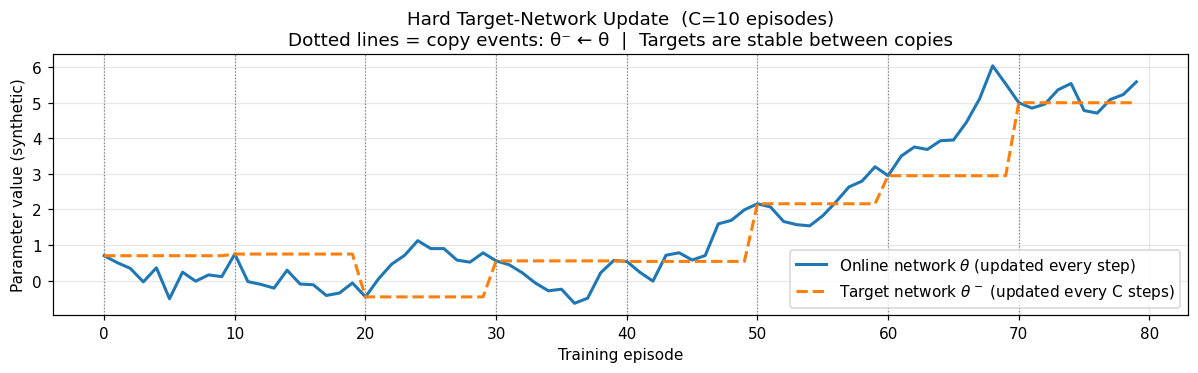

In [8]:
# ── Visualise hard target-update schedule ────────────────────────────────────
np.random.seed(1)
C = 10         # update every C episodes (scaled down for CartPole demo)
T = 80

theta_online = np.cumsum(np.random.randn(T) * 0.4 + 0.05)   # synthetic param trace
theta_target = np.zeros(T)
current = theta_online[0]
for t in range(T):
    if t % C == 0:
        current = theta_online[t]
    theta_target[t] = current

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(theta_online, lw=2, label=r'Online network $\theta$ (updated every step)')
ax.plot(theta_target, lw=2, linestyle='--', color='C1',
        label=r'Target network $\theta^-$ (updated every C steps)')
for t in range(0, T, C):
    ax.axvline(t, color='gray', lw=0.8, linestyle=':')
ax.set_xlabel('Training episode')
ax.set_ylabel('Parameter value (synthetic)')
ax.set_title(f'Hard Target-Network Update  (C={C} episodes)\n'
             f'Dotted lines = copy events: θ⁻ ← θ  |  Targets are stable between copies')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7 — Exploration: ε-Greedy with Linear Annealing

### Behaviour policy
$$a_t = \begin{cases} \text{random action} & \text{with probability } \varepsilon_t \\ \arg\max_a Q(s_t, a;\theta) & \text{otherwise} \end{cases}$$

### Linear annealing schedule
$\varepsilon$ decays **linearly** from $\varepsilon_{\text{start}} = 1.0$ to $\varepsilon_{\text{end}} = 0.1$
over the first $1{,}000{,}000$ **frames** (not episodes), then stays at 0.1.

| Why | Explanation |
|-----|-------------|
| **Start at 1.0** | Fill the replay buffer with diverse transitions; random exploration is unbiased |
| **End at 0.1** | Maintain residual exploration throughout training; prevents policy collapse |
| **Linear decay** | Simple, predictable; annealing speed is a tunable hyperparameter |

### In our CartPole demo
$\varepsilon: 1.0 \to 0.01$ over 300 episodes (scaled down from 1M Atari frames).

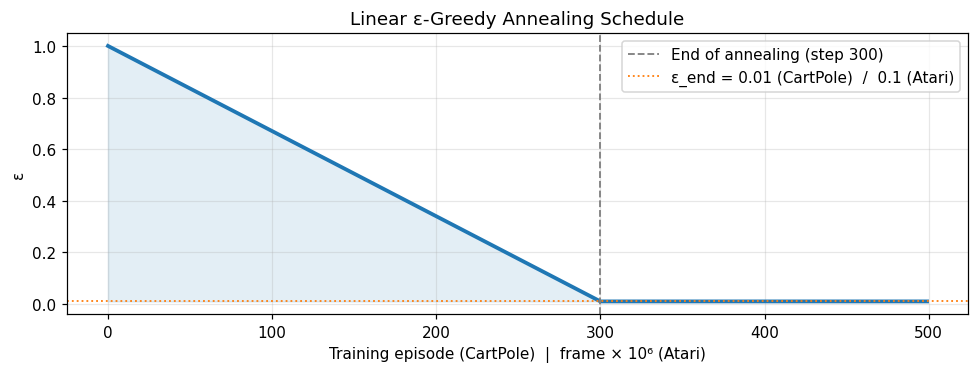

ε at step   0: 1.00  (pure exploration)
ε at step 150: 0.51  (50/50)
ε at step 300: 0.01  (mostly exploitation)
ε at step 500: 0.01  (plateau)


In [9]:
def linear_epsilon(step, eps_start=1.0, eps_end=0.01, eps_steps=300):
    """Linear annealing from eps_start to eps_end over eps_steps steps."""
    return max(eps_end, eps_start - (eps_start - eps_end) * step / eps_steps)

steps = np.arange(500)
eps_vals = [linear_epsilon(s) for s in steps]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(steps, eps_vals, lw=2.5, color='C0')
ax.axvline(300, color='gray', lw=1.2, linestyle='--', label='End of annealing (step 300)')
ax.axhline(0.01, color='C1', lw=1.2, linestyle=':', label='ε_end = 0.01 (CartPole)  /  0.1 (Atari)')
ax.fill_between(steps, eps_vals, 0.01, alpha=0.12, color='C0')
ax.set_xlabel('Training episode (CartPole)  |  frame × 10⁶ (Atari)')
ax.set_ylabel('ε')
ax.set_title('Linear ε-Greedy Annealing Schedule')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'ε at step   0: {linear_epsilon(0):.2f}  (pure exploration)')
print(f'ε at step 150: {linear_epsilon(150):.2f}  (50/50)')
print(f'ε at step 300: {linear_epsilon(300):.2f}  (mostly exploitation)')
print(f'ε at step 500: {linear_epsilon(500):.2f}  (plateau)')

---
## 8 — Loss Function and Reward Clipping

### Reward clipping
The paper trains a **single agent on 49 Atari games** with identical hyperparameters.
Different games have wildly different score scales (Pong: ±1, Centipede: up to 10,000).
Fix: clip all rewards to $[-1, +1]$ before storing in the buffer.

**Trade-off:** Loses reward magnitude information — a score of 1000 and 1 look the same.
Acceptable as a normalisation device; not needed when training on a single environment.

### Huber loss ("clipped error" in the paper)

The paper describes clipping the per-sample gradient to $[-1, +1]$, which is equivalent to
the **Huber loss** (PyTorch: `F.smooth_l1_loss` with default `beta=1`):

$$\mathcal{L}(\delta) = \begin{cases} \tfrac{1}{2}\delta^2 & |\delta| \le 1 \\ |\delta| - \tfrac{1}{2} & |\delta| > 1 \end{cases}$$

**Why not MSE?** In early training, TD errors $\delta$ can be very large (e.g. 50–100).
MSE gradient $= \delta$ would be 50–100 — effectively a very large learning rate for those
samples, causing instability.  Huber loss bounds the gradient to $|\nabla| \le 1$.

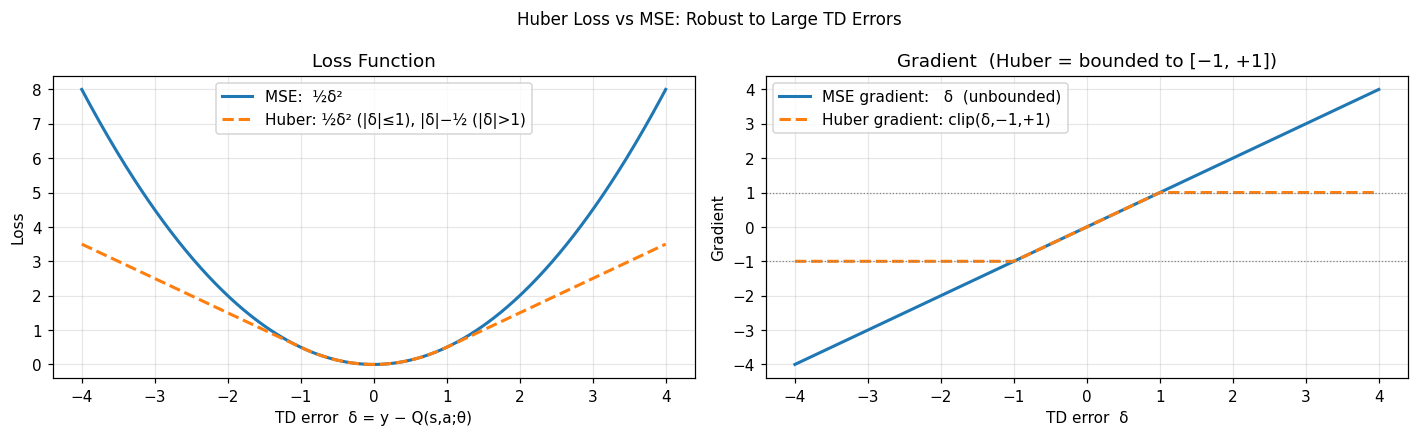

PyTorch smooth_l1_loss (beta=1): [2.5   0.125 0.    0.125 2.5  ]
Manual Huber:           [2.5   0.125 0.    0.125 2.5  ]


In [10]:
delta = np.linspace(-4, 4, 400)
mse_loss   = 0.5 * delta**2
huber_loss = np.where(np.abs(delta) <= 1, 0.5 * delta**2, np.abs(delta) - 0.5)
mse_grad   = delta
huber_grad = np.where(np.abs(delta) <= 1, delta, np.sign(delta))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(delta, mse_loss,   lw=2, label='MSE:  ½δ²')
ax1.plot(delta, huber_loss, lw=2, label='Huber: ½δ² (|δ|≤1), |δ|−½ (|δ|>1)', linestyle='--')
ax1.set_xlabel('TD error  δ = y − Q(s,a;θ)')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Function')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(delta, mse_grad,   lw=2, label='MSE gradient:   δ  (unbounded)')
ax2.plot(delta, huber_grad, lw=2, label='Huber gradient: clip(δ,−1,+1)', linestyle='--')
ax2.axhline( 1, color='gray', lw=0.8, linestyle=':')
ax2.axhline(-1, color='gray', lw=0.8, linestyle=':')
ax2.set_xlabel('TD error  δ')
ax2.set_ylabel('Gradient')
ax2.set_title('Gradient  (Huber = bounded to [−1, +1])')
ax2.legend(); ax2.grid(True, alpha=0.3)

fig.suptitle('Huber Loss vs MSE: Robust to Large TD Errors', fontsize=11)
plt.tight_layout()
plt.show()

# PyTorch verification
td_errors = torch.tensor([-3.0, -0.5, 0.0, 0.5, 3.0])
zeros = torch.zeros_like(td_errors)
print('PyTorch smooth_l1_loss (beta=1):',
      F.smooth_l1_loss(td_errors, zeros, reduction='none').numpy())
print('Manual Huber:          ',
      np.where(np.abs(td_errors.numpy()) <= 1,
               0.5*td_errors.numpy()**2,
               np.abs(td_errors.numpy()) - 0.5))

---
## 9 — Full DQN Agent

### Algorithm 1 from the paper (annotated)

```
INITIALISE  D  ← ReplayBuffer(N = 1,000,000)        ← experience replay
            θ  ← random                              ← online Q-network
            θ⁻ ← θ                                   ← target network

FOR episode = 1 … M:
  s ← env.reset()
  s ← preprocess(s)                                  ← grayscale + resize + stack 4

  FOR t = 1 … T:
    a ← ε-greedy(Q(s; θ), ε)                         ← exploration
    r, s' ← env.step(a)
    r ← clip(r, −1, +1)                              ← reward clipping
    D.push(s, a, r, s')

    {sⱼ, aⱼ, rⱼ, s'ⱼ} ← D.sample(32)               ← random mini-batch
    yⱼ ← rⱼ  +  γ max_a' Q(s'ⱼ, a'; θ⁻)            ← frozen target network
    θ  ← θ − α ∇_θ Σⱼ L_Huber(yⱼ − Q(sⱼ, aⱼ; θ))  ← Huber loss gradient step

    IF steps % C == 0:  θ⁻ ← θ                       ← hard target update
    s ← s'
```

### Hyperparameters (Nature DQN)

| Param | Value | Param | Value |
|-------|-------|-------|-------|
| Buffer $N$ | 1,000,000 | Replay start | 50,000 transitions |
| Mini-batch $B$ | 32 | Target update $C$ | 10,000 steps |
| Discount $\gamma$ | 0.99 | Learning rate | 0.00025 |
| $\varepsilon$: start→end | 1.0 → 0.1 | Optimizer | RMSprop (ρ=0.95) |
| Anneal frames | 1,000,000 | Frame skip | 4 |

In [11]:
class DQNAgent:
    """
    DQN agent implementing all tricks from Mnih et al. 2015.
    Each trick can be toggled via constructor flags for ablation experiments.
    """

    def __init__(
        self,
        state_dim: int,
        n_actions: int,
        # Network
        hidden_dim: int = 128,
        lr: float = 5e-4,
        gamma: float = 0.99,
        # ── Trick 1: Experience Replay ──────────────────────────────────────────
        use_replay: bool = True,
        buffer_size: int = 10_000,
        batch_size: int = 64,
        min_replay_size: int = 256,     # don't train until buffer has this many transitions
        # ── Trick 2: Target Network ─────────────────────────────────────────────
        use_target_net: bool = True,
        target_update_freq: int = 10,   # episodes between hard updates (θ⁻ ← θ)
        # ── Trick 3: ε-Greedy Annealing ────────────────────────────────────────
        eps_start: float = 1.0,
        eps_end: float = 0.01,
        eps_decay_steps: int = 300,
        # ── Trick 4: Huber Loss ─────────────────────────────────────────────────
        use_huber: bool = True,
        # ── Trick 5: Reward Clipping ────────────────────────────────────────────
        clip_reward: bool = False,
    ):
        self.n_actions          = n_actions
        self.gamma              = gamma
        self.batch_size         = batch_size
        self.min_replay_size    = min_replay_size
        self.use_replay         = use_replay
        self.use_target_net     = use_target_net
        self.use_huber          = use_huber
        self.clip_reward        = clip_reward
        self.target_update_freq = target_update_freq

        # Online Q-network
        self.q_net = CartPoleQNetwork(state_dim, n_actions, hidden_dim).to(device)

        # Target network — frozen copy, periodically synced
        if use_target_net:
            self.target_net = copy.deepcopy(self.q_net)
            self.target_net.eval()

        # Paper uses RMSprop; Adam is also widely used in practice
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)

        # Replay buffer
        if use_replay:
            self.buffer = ReplayBuffer(buffer_size)

        # Exploration state
        self.eps_start      = eps_start
        self.eps_end        = eps_end
        self.eps_decay_steps= eps_decay_steps
        self.steps_done     = 0
        self.episodes_done  = 0
        self.losses         = []

    @property
    def epsilon(self) -> float:
        """Current exploration probability (linear annealing)."""
        return max(
            self.eps_end,
            self.eps_start
            - (self.eps_start - self.eps_end) * self.steps_done / self.eps_decay_steps
        )

    def select_action(self, state: np.ndarray) -> int:
        """ε-greedy action selection."""
        self.steps_done += 1
        if random.random() < self.epsilon:
            return random.randrange(self.n_actions)
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0).to(device)
            return self.q_net(s).argmax(dim=1).item()

    def _compute_loss(self, states, actions, rewards, next_states, dones) -> torch.Tensor:
        states_t      = torch.FloatTensor(states).to(device)
        actions_t     = torch.LongTensor(actions).to(device)
        rewards_t     = torch.FloatTensor(rewards).to(device)
        next_states_t = torch.FloatTensor(next_states).to(device)
        dones_t       = torch.FloatTensor(dones).to(device)

        # Q(s, a; θ)  — only the action that was taken
        q_vals = self.q_net(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)

        # y = r + γ max_a' Q(s', a'; θ⁻)   [no gradient through target]
        with torch.no_grad():
            net = self.target_net if self.use_target_net else self.q_net
            next_q  = net(next_states_t).max(dim=1)[0]
            targets = rewards_t + self.gamma * next_q * (1.0 - dones_t)

        return F.smooth_l1_loss(q_vals, targets) if self.use_huber else F.mse_loss(q_vals, targets)

    def train_step(self, state, action, reward, next_state, done):
        """Process one transition and take a gradient step."""
        if self.clip_reward:
            reward = float(np.clip(reward, -1.0, 1.0))

        if self.use_replay:
            self.buffer.push(state, action, reward, next_state, done)
            if not self.buffer.is_ready(max(self.batch_size, self.min_replay_size)):
                return
            batch = self.buffer.sample(self.batch_size)
        else:
            # Online update — single transition, no replay
            batch = (
                np.array([state]), np.array([action]), np.array([reward]),
                np.array([next_state]), np.array([float(done)]),
            )

        loss = self._compute_loss(*batch)
        self.optimizer.zero_grad()
        loss.backward()
        # Paper clips per-weight gradient norms (equivalent to Huber for per-sample gradients)
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), max_norm=10.0)
        self.optimizer.step()
        self.losses.append(loss.item())

    def end_episode(self):
        """Must be called after each episode; handles target network sync."""
        self.episodes_done += 1
        if self.use_target_net and self.episodes_done % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())   # hard update


print('DQNAgent defined — all 5 tricks toggleable via constructor flags.')

DQNAgent defined — all 5 tricks toggleable via constructor flags.


In [12]:
# ── Training loop ─────────────────────────────────────────────────────────────

def train(agent: DQNAgent, env_name: str = 'CartPole-v1',
          n_episodes: int = 400, seed: int = 0) -> list:
    """Run the DQN training loop for n_episodes; return per-episode rewards."""
    env = gym.make(env_name)
    rewards = []
    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        total, done = 0.0, False
        while not done:
            action = agent.select_action(state)
            next_state, reward, term, trunc, _ = env.step(action)
            done = term or trunc
            agent.train_step(state, action, reward, next_state, done)
            state = next_state
            total += reward
        agent.end_episode()
        rewards.append(total)
    env.close()
    return rewards


def run_seeds(config: dict, n_seeds: int = 5, n_episodes: int = 400,
              state_dim: int = 4, n_actions: int = 2) -> np.ndarray:
    """Train n_seeds independent agents; return (n_seeds, n_episodes) reward array."""
    all_rewards = []
    for s in range(n_seeds):
        torch.manual_seed(s); np.random.seed(s); random.seed(s)
        agent = DQNAgent(state_dim=state_dim, n_actions=n_actions, **config)
        all_rewards.append(train(agent, n_episodes=n_episodes, seed=s * 100))
    return np.array(all_rewards)


print('train() and run_seeds() defined.')

train() and run_seeds() defined.


---
## 10 — Ablation Studies

We train four variants of the agent to isolate the contribution of the two main tricks:

| Variant | Experience Replay | Target Network |
|---------|:-----------------:|:--------------:|
| **Full DQN** | ✓ | ✓ |
| No Target Net | ✓ | ✗ |
| No Replay | ✗ | ✓ |
| No Replay + No Target | ✗ | ✗ |

We also compare **Huber loss vs MSE** as a fifth condition.  
All other hyperparameters are identical; 5 seeds each.

In [13]:
N_SEEDS    = 5
N_EPISODES = 400

# ── Ablation configs ──────────────────────────────────────────────────────────
BASE = dict(eps_decay_steps=300, target_update_freq=10)

configs = {
    'Full DQN':              dict(**BASE, use_replay=True,  use_target_net=True,  use_huber=True),
    'No Target Net':         dict(**BASE, use_replay=True,  use_target_net=False, use_huber=True),
    'No Replay':             dict(**BASE, use_replay=False, use_target_net=True,  use_huber=True),
    'No Replay + No Target': dict(**BASE, use_replay=False, use_target_net=False, use_huber=True),
}

results = {}
for name, cfg in configs.items():
    print(f'Training: {name} ...')
    results[name] = run_seeds(cfg, n_seeds=N_SEEDS, n_episodes=N_EPISODES)
    final = np.mean(results[name][:, -50:])
    print(f'  Final 50-ep mean: {final:.1f}')

# Huber vs MSE
print('Training: Full DQN (MSE loss) ...')
results['Full DQN (MSE)'] = run_seeds(
    dict(**BASE, use_replay=True, use_target_net=True, use_huber=False),
    n_seeds=N_SEEDS, n_episodes=N_EPISODES
)
print(f'  Final 50-ep mean: {np.mean(results["Full DQN (MSE)"][:, -50:]):.1f}')

Training: Full DQN ...
  Final 50-ep mean: 213.4
Training: No Target Net ...
  Final 50-ep mean: 9.4
Training: No Replay ...
  Final 50-ep mean: 9.4
Training: No Replay + No Target ...
  Final 50-ep mean: 9.4
Training: Full DQN (MSE loss) ...
  Final 50-ep mean: 200.6


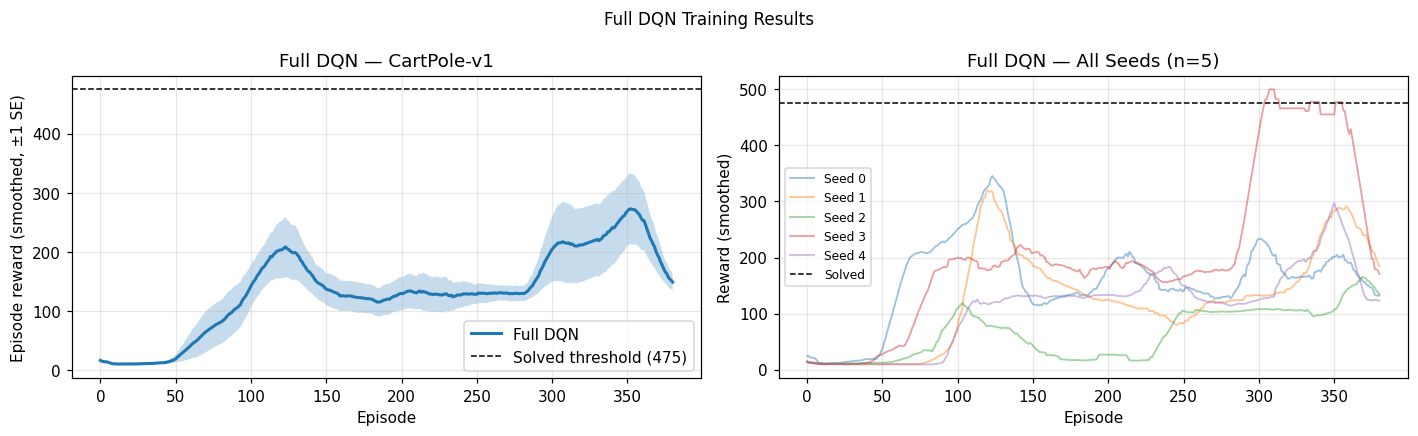

In [14]:
# ── Plot 1: Full DQN learning curve ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

full_r = results['Full DQN']
mean_s = smooth(full_r.mean(0), 20)
se_s   = smooth(full_r.std(0) / np.sqrt(N_SEEDS), 20)
x = np.arange(len(mean_s))

ax = axes[0]
ax.plot(x, mean_s, lw=2, label='Full DQN')
ax.fill_between(x, mean_s - se_s, mean_s + se_s, alpha=0.25)
ax.axhline(475, color='k', lw=1, linestyle='--', label='Solved threshold (475)')
ax.set_xlabel('Episode'); ax.set_ylabel('Episode reward (smoothed, ±1 SE)')
ax.set_title('Full DQN — CartPole-v1')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
for i, r in enumerate(full_r):
    ax.plot(smooth(r, 20), alpha=0.45, lw=1.2, label=f'Seed {i}')
ax.axhline(475, color='k', lw=1, linestyle='--', label='Solved')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward (smoothed)')
ax.set_title(f'Full DQN — All Seeds (n={N_SEEDS})')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle('Full DQN Training Results', fontsize=11)
plt.tight_layout()
plt.show()

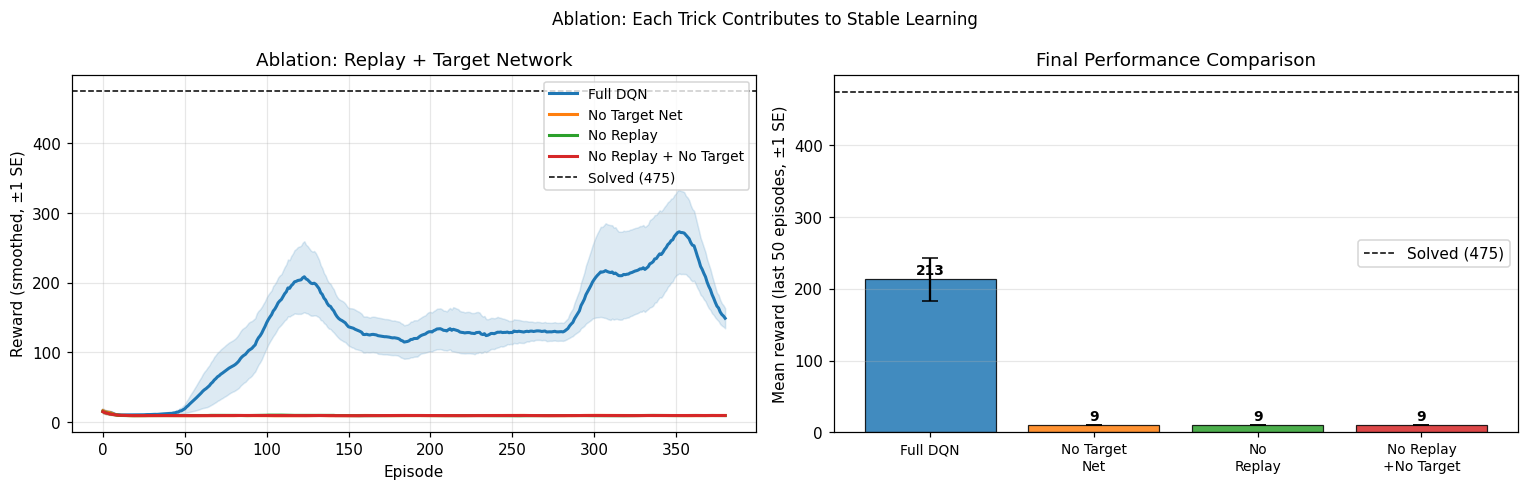

In [15]:
# ── Plot 2: Ablation — replay + target network ────────────────────────────────
ablation_keys = ['Full DQN', 'No Target Net', 'No Replay', 'No Replay + No Target']
colors = ['C0', 'C1', 'C2', 'C3']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Learning curves
ax = axes[0]
for key, color in zip(ablation_keys, colors):
    r = results[key]
    m = smooth(r.mean(0), 20)
    se = smooth(r.std(0) / np.sqrt(N_SEEDS), 20)
    x = np.arange(len(m))
    ax.plot(x, m, lw=2, label=key, color=color)
    ax.fill_between(x, m - se, m + se, alpha=0.15, color=color)
ax.axhline(475, color='k', lw=1, linestyle='--', label='Solved (475)')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward (smoothed, ±1 SE)')
ax.set_title('Ablation: Replay + Target Network')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Final performance bar chart
ax = axes[1]
final_means = [np.mean(results[k][:, -50:]) for k in ablation_keys]
final_ses   = [np.std(results[k][:, -50:].mean(1)) / np.sqrt(N_SEEDS) for k in ablation_keys]
bars = ax.bar(range(len(ablation_keys)), final_means, yerr=final_ses,
              color=colors, capsize=5, alpha=0.85, edgecolor='black', linewidth=0.8)
ax.axhline(475, color='k', lw=1, linestyle='--', label='Solved (475)')
ax.set_xticks(range(len(ablation_keys)))
ax.set_xticklabels(['Full DQN', 'No Target\nNet', 'No\nReplay', 'No Replay\n+No Target'],
                   fontsize=9)
ax.set_ylabel('Mean reward (last 50 episodes, ±1 SE)')
ax.set_title('Final Performance Comparison')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, final_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Ablation: Each Trick Contributes to Stable Learning', fontsize=11)
plt.tight_layout()
plt.show()

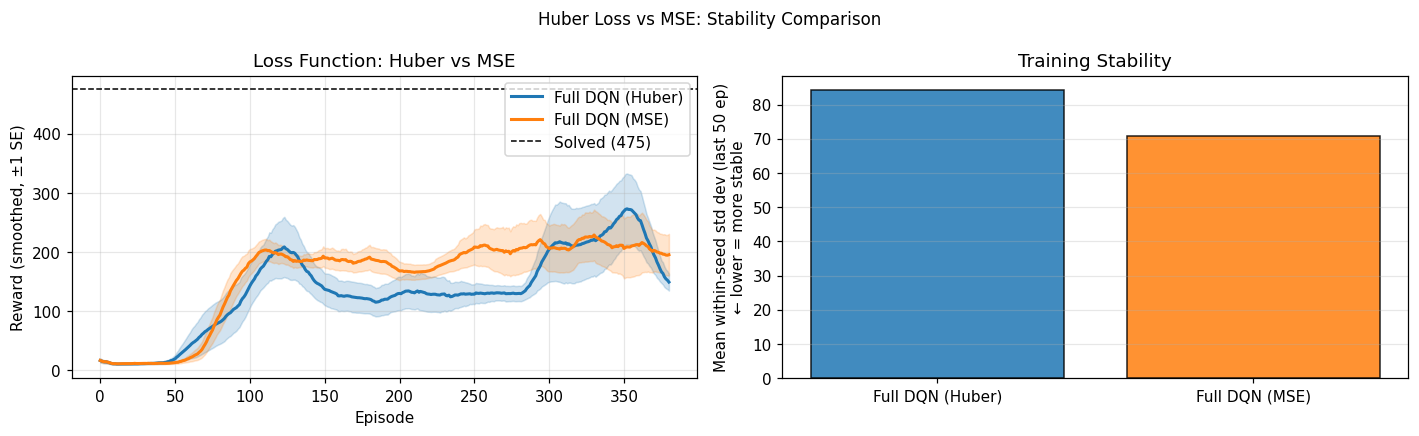

In [16]:
# ── Plot 3: Huber loss vs MSE ablation ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

loss_pairs = [
    ('Full DQN (Huber)', results['Full DQN'],       'C0'),
    ('Full DQN (MSE)',   results['Full DQN (MSE)'], 'C1'),
]

for label, r, color in loss_pairs:
    m  = smooth(r.mean(0), 20)
    se = smooth(r.std(0) / np.sqrt(N_SEEDS), 20)
    x  = np.arange(len(m))
    ax1.plot(x, m, lw=2, label=label, color=color)
    ax1.fill_between(x, m - se, m + se, alpha=0.2, color=color)

ax1.axhline(475, color='k', lw=1, linestyle='--', label='Solved (475)')
ax1.set_xlabel('Episode'); ax1.set_ylabel('Reward (smoothed, ±1 SE)')
ax1.set_title('Loss Function: Huber vs MSE')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Variance of rewards in last 50 episodes (stability measure)
stabilities = {label: r[:, -50:].std(axis=1).mean() for label, r, _ in loss_pairs}
ax2.bar(stabilities.keys(), stabilities.values(),
        color=['C0', 'C1'], alpha=0.85, edgecolor='black')
ax2.set_ylabel('Mean within-seed std dev (last 50 ep)\n← lower = more stable')
ax2.set_title('Training Stability')
ax2.grid(True, alpha=0.3, axis='y')

fig.suptitle('Huber Loss vs MSE: Stability Comparison', fontsize=11)
plt.tight_layout()
plt.show()

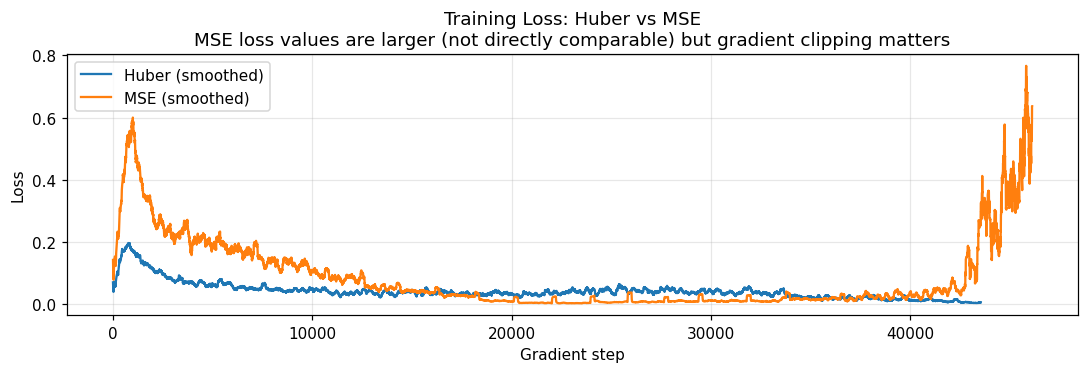

In [17]:
# ── Training loss curves: Huber vs MSE ───────────────────────────────────────
# Train two fresh agents for a single seed and record their loss curves
torch.manual_seed(0); np.random.seed(0); random.seed(0)
agent_huber = DQNAgent(4, 2, **dict(BASE, use_replay=True, use_target_net=True, use_huber=True))
_ = train(agent_huber, n_episodes=300, seed=0)

torch.manual_seed(0); np.random.seed(0); random.seed(0)
agent_mse   = DQNAgent(4, 2, **dict(BASE, use_replay=True, use_target_net=True, use_huber=False))
_ = train(agent_mse, n_episodes=300, seed=0)

fig, ax = plt.subplots(figsize=(10, 3.5))
for label, agent, color in [('Huber', agent_huber, 'C0'), ('MSE', agent_mse, 'C1')]:
    losses = np.array(agent.losses)
    ax.plot(smooth(losses, 200), lw=1.5, label=f'{label} (smoothed)', color=color)
ax.set_xlabel('Gradient step'); ax.set_ylabel('Loss')
ax.set_title('Training Loss: Huber vs MSE\n'
             'MSE loss values are larger (not directly comparable) but gradient clipping matters')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

### DQN Tricks and Why They Work

| Trick | Problem Solved | Key Detail |
|-------|---------------|------------|
| **Deep CNN** | Raw pixel state space (210×160×3) | Conv → FC → Q(s,·) for all actions in one pass |
| **Experience Replay** | Correlated updates; low data efficiency | Random mini-batch from circular buffer of 1M transitions |
| **Target Network** | Moving/non-stationary targets | Frozen copy θ⁻; hard update every C=10,000 steps |
| **Frame stacking (×4)** | Velocity invisible in single frame | 4 consecutive frames → implicit recurrence |
| **Frame preprocessing** | Redundant colour, oversized input | Grayscale + 84×84 resize + uint8 storage |
| **ε-Greedy annealing** | Need exploration early, exploitation later | Linear 1.0→0.1 over 1M frames |
| **Reward clipping** | Inconsistent reward scales across 49 games | clip(r, −1, +1) |
| **Huber loss** | Exploding gradients for large TD errors | Quadratic near 0, linear (bounded gradient) for |δ|>1 |
| **Action repeat (×4)** | Speed; smoother decision frequency | Same action for 4 frames, max over last 2 |
| **Replay start size** | Poor quality buffer at beginning | Wait 50,000 transitions before first gradient step |

### What Came Next (Selected)

| Algorithm | Key Improvement |
|-----------|----------------|
| **Double DQN** (DDQN, 2015) | Fixes Q-value overestimation: use θ to *select*, θ⁻ to *evaluate* |
| **Dueling DQN** (2015) | Separate heads for V(s) and A(s,a); learns state value without needing all actions |
| **Prioritised Replay** (PER, 2015) | Sample high-TD-error transitions more often; importance-sampling correction |
| **A3C** (2016) | Asynchronous actors replace replay buffer; on-policy, naturally diverse data |
| **Rainbow** (2017) | Combines 6 improvements: DDQN + Dueling + PER + n-step + Distributional + Noisy nets |